In [5]:
import pandas as pd
import numpy as np
import re
import os
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
from tqdm import tqdm

train_df = pd.read_csv('data/train_raw.csv')
valid_df = pd.read_csv('data/valid_raw.csv')
test_df  = pd.read_csv('data/test_raw.csv')

print(f"Train: {len(train_df)} | Valid: {len(valid_df)} | Test: {len(test_df)}")
print(train_df.head(2))

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Train: 21854 | Valid: 2732 | Test: 2732
   id                                               func  target project  \
0   0  static av_cold int vdadec_init(AVCodecContext ...   False  FFmpeg   
1   1  static int transcode(AVFormatContext **output_...   False  FFmpeg   

                                  commit_id  code_length  
0  973b1a6b9070e2bf17d17568cbaf4043ce931f51         2221  
1  321b2a9ded0468670b7678b7c098886930ae16b2        36873  


In [6]:
def clean_code(code: str) -> str:
    """
    Light-touch cleaning for C/C++ source code.
    We preserve structure (indentation, brackets) since they carry semantic meaning.
    """
    if not isinstance(code, str):
        return ""

    # Remove multi-line comments /* ... */
    code = re.sub(r'/\*.*?\*/', '', code, flags=re.DOTALL)

    # Remove single-line comments // ...
    code = re.sub(r'//[^\n]*', '', code)

    # Collapse multiple blank lines into one
    code = re.sub(r'\n\s*\n\s*\n', '\n\n', code)

    # Strip leading/trailing whitespace
    code = code.strip()

    return code


# Apply cleaning
for df in [train_df, valid_df, test_df]:
    df['clean_code'] = df['func'].apply(clean_code)

# Verify
sample_idx = 0
print("BEFORE CLEANING:")
print(train_df['func'][sample_idx][:400])
print("\nAFTER CLEANING:")
print(train_df['clean_code'][sample_idx][:400])

BEFORE CLEANING:
static av_cold int vdadec_init(AVCodecContext *avctx)

{

    VDADecoderContext *ctx = avctx->priv_data;

    struct vda_context *vda_ctx = &ctx->vda_ctx;

    OSStatus status;

    int ret;



    ctx->h264_initialized = 0;



    /* init pix_fmts of codec */

    if (!ff_h264_vda_decoder.pix_fmts) {

        if (kCFCoreFoundationVersionNumber < kCFCoreFoundationVersionNumber10_7)

            ff

AFTER CLEANING:
static av_cold int vdadec_init(AVCodecContext *avctx)

{

    VDADecoderContext *ctx = avctx->priv_data;

    struct vda_context *vda_ctx = &ctx->vda_ctx;

    OSStatus status;

    int ret;

    ctx->h264_initialized = 0;

    if (!ff_h264_vda_decoder.pix_fmts) {

        if (kCFCoreFoundationVersionNumber < kCFCoreFoundationVersionNumber10_7)

            ff_h264_vda_decoder.pix_fmts = vda_pixfm


In [7]:
# Check for empty / null samples after cleaning
for name, df in [('Train', train_df), ('Valid', valid_df), ('Test', test_df)]:
    empty = df['clean_code'].apply(lambda x: len(x.strip()) == 0).sum()
    print(f"{name}: {empty} empty samples (will be dropped)")
    df.drop(df[df['clean_code'].str.strip().str.len() == 0].index, inplace=True)
    df.reset_index(drop=True, inplace=True)

Train: 0 empty samples (will be dropped)
Valid: 0 empty samples (will be dropped)
Test: 0 empty samples (will be dropped)


In [8]:
MODEL_NAME  = "microsoft/codebert-base"
MAX_LENGTH  = 512  # CodeBERT max token length

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded! Vocab size:", tokenizer.vocab_size)

Loading tokenizer: microsoft/codebert-base


Tokenizer loaded! Vocab size: 50265


In [9]:
# Quick tokenization demo
sample = train_df['clean_code'][0][:200]
tokens = tokenizer(sample, return_tensors='pt', max_length=MAX_LENGTH, truncation=True)

print("Sample code snippet:")
print(sample)
print(f"\nToken IDs shape: {tokens['input_ids'].shape}")
print(f"Decoded tokens:  {tokenizer.convert_ids_to_tokens(tokens['input_ids'][0][:20])}")

Sample code snippet:
static av_cold int vdadec_init(AVCodecContext *avctx)

{

    VDADecoderContext *ctx = avctx->priv_data;

    struct vda_context *vda_ctx = &ctx->vda_ctx;

    OSStatus status;

    int ret;

    ctx-

Token IDs shape: torch.Size([1, 90])
Decoded tokens:  ['<s>', 'static', 'Ġav', '_', 'cold', 'Ġint', 'Ġv', 'd', 'ade', 'c', '_', 'init', '(', 'AV', 'Cod', 'ec', 'Context', 'Ġ*', 'av', 'ctx']


In [10]:
class CodeDefectDataset(Dataset):
    """
    PyTorch Dataset for code defect detection.
    Each item returns tokenized input_ids, attention_mask, and label.
    """

    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_length: int = 512):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        code  = str(self.data.loc[idx, 'clean_code'])
        label = int(self.data.loc[idx, 'target'])

        encoding = self.tokenizer(
            code,
            max_length     = self.max_length,
            padding        = 'max_length',
            truncation     = True,
            return_tensors = 'pt'
        )

        return {
            'input_ids'      : encoding['input_ids'].squeeze(0),       # [max_length]
            'attention_mask' : encoding['attention_mask'].squeeze(0),  # [max_length]
            'label'          : torch.tensor(label, dtype=torch.long)
        }


# Create datasets
train_dataset = CodeDefectDataset(train_df, tokenizer, MAX_LENGTH)
valid_dataset = CodeDefectDataset(valid_df, tokenizer, MAX_LENGTH)
test_dataset  = CodeDefectDataset(test_df,  tokenizer, MAX_LENGTH)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Valid dataset: {len(valid_dataset)} samples")
print(f"Test  dataset: {len(test_dataset)} samples")

# Verify a sample
sample_item = train_dataset[0]
print(f"\nSample item keys: {list(sample_item.keys())}")
print(f"input_ids shape:  {sample_item['input_ids'].shape}")
print(f"label:            {sample_item['label']}")

Train dataset: 21854 samples
Valid dataset: 2732 samples
Test  dataset: 2732 samples

Sample item keys: ['input_ids', 'attention_mask', 'label']
input_ids shape:  torch.Size([512])
label:            0


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16  # Reduce to 8 if you get CUDA out-of-memory

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Test one batch
batch = next(iter(train_loader))
print(f"Batch input_ids shape:      {batch['input_ids'].shape}")
print(f"Batch attention_mask shape: {batch['attention_mask'].shape}")
print(f"Batch labels:               {batch['label']}")

Batch input_ids shape:      torch.Size([16, 512])
Batch attention_mask shape: torch.Size([16, 512])
Batch labels:               tensor([1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0])


In [12]:
os.makedirs('data', exist_ok=True)
train_df[['clean_code', 'target']].to_csv('data/train_clean.csv', index=False)
valid_df[['clean_code', 'target']].to_csv('data/valid_clean.csv', index=False)
test_df [['clean_code', 'target']].to_csv('data/test_clean.csv',  index=False)

# Save tokenizer for re-use in later notebooks
os.makedirs('tokenizer', exist_ok=True)
tokenizer.save_pretrained('tokenizer/')

print("✅ Cleaned CSVs saved to data/")
print("✅ Tokenizer saved to tokenizer/")

✅ Cleaned CSVs saved to data/
✅ Tokenizer saved to tokenizer/


Calculating token lengths: 100%|██████████| 1000/1000 [00:01<00:00, 506.51it/s]


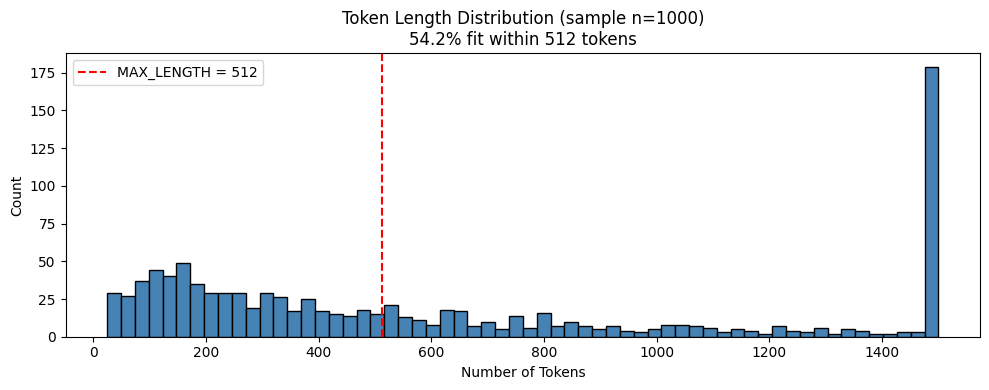

Mean token length:   1103
Median token length: 448
Max token length:    81754
% within 512 tokens: 54.2%


In [13]:
import matplotlib.pyplot as plt

# Calculate token lengths for a sample of train data
sample_codes = train_df['clean_code'].sample(1000, random_state=42).tolist()
token_lengths = []
for code in tqdm(sample_codes, desc='Calculating token lengths'):
    ids = tokenizer(code, truncation=False)['input_ids']
    token_lengths.append(len(ids))

token_lengths = np.array(token_lengths)
pct_within_512 = (token_lengths <= 512).mean() * 100

plt.figure(figsize=(10, 4))
plt.hist(token_lengths.clip(max=1500), bins=60, color='steelblue', edgecolor='black')
plt.axvline(x=512, color='red', linestyle='--', label='MAX_LENGTH = 512')
plt.title(f'Token Length Distribution (sample n=1000)\n{pct_within_512:.1f}% fit within 512 tokens')
plt.xlabel('Number of Tokens')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=150)
plt.show()

print(f"Mean token length:   {token_lengths.mean():.0f}")
print(f"Median token length: {np.median(token_lengths):.0f}")
print(f"Max token length:    {token_lengths.max()}")
print(f"% within 512 tokens: {pct_within_512:.1f}%")